# 04b - Entrenamiento de LightGBM

Este notebook entrena el primer modelo no lineal de *gradient boosting* considerado en el proyecto: LightGBM.

A diferencia de la regresión lineal, LightGBM sí dispone de hiperparámetros relevantes. Por ello, dentro del bloque de entrenamiento, se aplicará una validación cruzada de series temporales con origen de predicción variable (*time series cross-validation* / *rolling forecasting origin*, tal y como sugiere Hyndman en https://otexts.com/fpppy/05-toolbox.html#sec-tscv) respetando el orden cronológico de la serie.

El objetivo de este notebook es obtener predicciones puntuales para los horizontes de comparación inicial, con carácter previo a la selección del modelo definitivo:

- 1 hora
- 4 horas
- 12 horas
- 24 horas

Nota metodológica: este notebook entrena la versión puntual de LightGBM. Las versiones cuantílicas necesarias para CQR se abordarán posteriormente, en la fase de cuantificación de la incertidumbre.

## Objetivos del notebook

1. Cargar los datasets de modelado por horizonte generados en `02_modeling_dataset_features`
2. Cargar el conjunto de variables predictoras definido en la fase de ingeniería de características
3. Aplicar validación interna con origen de predicción variable dentro del bloque de entrenamiento
4. Seleccionar una configuración de hiperparámetros de LightGBM para cada horizonte
5. Reajustar el modelo final con todo el bloque de entrenamiento
6. Generar predicciones puntuales sobre el conjunto de validación
7. Calcular las métricas MAE y RMSE para la comparación inicial de modelos
8. Guardar los modelos, las predicciones, las métricas y los resultados de la validación interna

El conjunto de prueba de 2025 no se utiliza en el presente notebook.

In [1]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Dict, List

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.metrics import mean_absolute_error, mean_squared_error

try:
    import lightgbm as lgb
    from lightgbm import LGBMRegressor
except ImportError as exc:
    raise ImportError(
        "No se ha podido importar LightGBM. Debe instalarse en el entorno del proyecto "
    ) from exc

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

In [ ]:
# Configuración general del notebook
# ==============================================================================
# El notebook puede ejecutarse desde la carpeta notebooks/ o desde la raíz del
# repositorio. Esta función localiza la raíz de forma dinámica.

def find_project_root(start: Path | None = None) -> Path:
    """Busca la raíz del proyecto partiendo del directorio actual.

    Esta función evita depender de rutas absolutas locales. Así, el notebook puede
    ejecutarse aunque el repositorio esté guardado en otra carpeta o se abra desde
    un directorio diferente dentro del proyecto.
    """
    current = Path.cwd() if start is None else start.resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data").exists() and (candidate / "reports").exists():
            return candidate

    raise FileNotFoundError(
        "No se pudo localizar la raíz del proyecto. Debe ejecutarse el notebook desde "
        "la raíz del repositorio o desde la carpeta notebooks/."
    )


PROJECT_ROOT = find_project_root()

DATA_MODELING_DIR = PROJECT_ROOT / "data" / "modeling"
REPORTS_TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
REPORTS_PREDICTIONS_DIR = PROJECT_ROOT / "reports" / "predictions"
REPORTS_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
MODELS_DIR = PROJECT_ROOT / "models" / "lightgbm"

for directory in [
    REPORTS_TABLES_DIR,
    REPORTS_PREDICTIONS_DIR,
    REPORTS_FIGURES_DIR,
    MODELS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

FEATURE_COLUMNS_PATH = DATA_MODELING_DIR / "feature_columns.json"

MODEL_NAME = "lightgbm"
HORIZONS = [1, 4, 12, 24]
MAX_EXPECTED_FEATURES = 25

RANDOM_STATE = 42

# Configuración de la validación interna.
# Se utilizan pocas particiones para mantener el entrenamiento razonable en coste
# computacional, pero siempre respetando el orden temporal.
MIN_TRAIN_DAYS = 365
INTERNAL_VALIDATION_DAYS = 90
INTERNAL_STEP_DAYS = 180
MAX_INTERNAL_FOLDS = 3

# Parámetros de entrenamiento de LightGBM.
MAX_ESTIMATORS = 1_000
EARLY_STOPPING_ROUNDS = 50

# Horizonte utilizado en las figuras de inspección visual.
EXAMPLE_HORIZON = 4
EXAMPLE_HOURS = 14 * 24

## Carga de las variables predictoras

El notebook `02_modeling_dataset_features` genera un archivo `feature_columns.json` con la lista de variables predictoras.

Se utiliza la lista específica de cada horizonte (`feature_columns_by_horizon`) porque algunas variables pueden coincidir exactamente para determinados horizontes. Por ejemplo, en h=24, la misma hora del día anterior al objetivo coincide con el valor observado en el origen de predicción.

In [ ]:
if not FEATURE_COLUMNS_PATH.exists():
    raise FileNotFoundError(
        "No se ha encontrado el archivo data/modeling/feature_columns.json. "
        "Debe ejecutarse primero el notebook 02_modeling_dataset_features."
    )

feature_payload = json.loads(FEATURE_COLUMNS_PATH.read_text(encoding="utf-8"))

feature_columns_by_horizon: Dict[str, List[str]] = feature_payload.get(
    "feature_columns_by_horizon",
    {},
)

default_feature_columns: List[str] = feature_payload.get(
    "candidate_feature_columns",
    feature_payload.get("feature_columns", []),
)

if not feature_columns_by_horizon and not default_feature_columns:
    raise ValueError(
        "El archivo feature_columns.json no contiene listas de variables predictoras."
    )

feature_summary_rows = []

for horizon in HORIZONS:
    feature_cols = feature_columns_by_horizon.get(str(horizon), default_feature_columns)

    feature_summary_rows.append(
        {
            "horizon": horizon,
            "n_features": len(feature_cols),
            "features": feature_cols,
        }
    )

    if len(feature_cols) > MAX_EXPECTED_FEATURES:
        raise AssertionError(
            f"El horizonte {horizon} contiene {len(feature_cols)} variables. "
            f"Se esperaba un conjunto de como máximo ({MAX_EXPECTED_FEATURES})."
        )

feature_summary_df = pd.DataFrame(feature_summary_rows)
display(feature_summary_df)

,horizon,n_features,features
0,1,21,"[target_hour_sin, target_hour_cos, target_dayo..."
1,4,21,"[target_hour_sin, target_hour_cos, target_dayo..."
2,12,20,"[target_hour_sin, target_hour_cos, target_dayo..."
3,24,20,"[target_hour_sin, target_hour_cos, target_dayo..."


## Carga de los datasets de modelado por horizonte

Cada dataset contiene filas de la forma:

$$
X_t \rightarrow y_{t+h}
$$

donde:

- `origin_timestamp` es el instante desde el que se formula la predicción
- `target_timestamp` es el instante objetivo
- `y` es la concentración de O3 que se desea predecir
- las variables predictoras se han construido con información disponible en `origin_timestamp` o antes, salvo las variables de calendario del objetivo, que se conocen de antemano

Nota: La partición cronológica ya está asignada en la columna `split`.

In [4]:
def load_modeling_dataset(horizon: int) -> pd.DataFrame:
    """Carga el dataset de modelado correspondiente a un horizonte."""
    file_path = DATA_MODELING_DIR / f"modeling_h{horizon:02d}.parquet"

    if not file_path.exists():
        raise FileNotFoundError(
            f"No se ha encontrado {file_path}. "
            "Debe ejecutarse primero el notebook 02_modeling_dataset_features."
        )

    df = pd.read_parquet(file_path)
    df = df.sort_values("target_timestamp").reset_index(drop=True)

    return df


datasets_by_horizon: Dict[int, pd.DataFrame] = {
    horizon: load_modeling_dataset(horizon)
    for horizon in HORIZONS
}

dataset_overview_rows = []

for horizon, df in datasets_by_horizon.items():
    dataset_overview_rows.append(
        {
            "horizon": horizon,
            "n_rows": len(df),
            "splits": sorted(df["split"].dropna().unique().tolist()),
            "target_min": df["target_timestamp"].min(),
            "target_max": df["target_timestamp"].max(),
            "missing_y": int(df["y"].isna().sum()),
        }
    )

dataset_overview_df = pd.DataFrame(dataset_overview_rows)
display(dataset_overview_df)

,horizon,n_rows,splits,target_min,target_max,missing_y
0,1,50941,"[calibration, test, train, validation]",2020-01-01 01:00:00,2025-12-31 23:00:00,0
1,4,50938,"[calibration, test, train, validation]",2020-01-01 04:00:00,2025-12-31 23:00:00,0
2,12,50930,"[calibration, test, train, validation]",2020-01-01 12:00:00,2025-12-31 23:00:00,0
3,24,50918,"[calibration, test, train, validation]",2020-01-02 00:00:00,2025-12-31 23:00:00,0


## Validación interna con origen de predicción variable

Para seleccionar hiperparámetros sin utilizar el conjunto de validación externa, se aplicará una técnica de validación interna dentro del bloque de entrenamiento.

El procedimiento sigue la lógica de *rolling forecasting origin*, es decir:

1. Se ajusta el modelo con un tramo inicial del conjunto de entrenamiento
2. Se evalúa sobre un tramo temporal posterior
3. El origen de predicción se desplaza hacia delante
4. Se repite el proceso varias veces

De esta forma, las configuraciones de LightGBM se comparan utilizando únicamente datos del bloque de entrenamiento, respetando la naturaleza secuencial de la serie.

In [ ]:
def compute_point_metrics(y_true: pd.Series, y_pred: np.ndarray) -> dict[str, float]:
    """Calcula métricas de predicción puntual."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    return {
        "mae": float(mae),
        "rmse": float(rmse),
    }


def prepare_xy_from_mask(
    df: pd.DataFrame,
    feature_columns: list[str],
    mask: pd.Series,
) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame]:
    """Extrae X, y y metadatos a partir de una máscara booleana.

    Se eliminan únicamente las filas sin variable objetivo (`y`), ya que no pueden
    utilizarse ni para ajustar ni para evaluar el modelo.

    Los valores ausentes en las variables predictoras se conservan porque LightGBM
    puede gestionarlos de forma nativa. Esto evita introducir una imputación global que pueda
    alterar la serie o introducir fuga temporal, como ya se ha indicado en anteriores notebooks.
    """
    split_df = df.loc[mask].copy()
    split_df = split_df.dropna(subset=["y"]).copy()

    missing_columns = [column for column in feature_columns if column not in split_df.columns]
    if missing_columns:
        raise ValueError(f"Faltan columnas predictoras: {missing_columns}")

    X = split_df[feature_columns].apply(pd.to_numeric, errors="coerce")
    y = split_df["y"].astype(float)

    metadata_columns = [
        "horizon",
        "split",
        "origin_timestamp",
        "target_timestamp",
    ]

    metadata = split_df[metadata_columns].copy()

    return X, y, metadata


def prepare_split(
    df: pd.DataFrame,
    feature_columns: list[str],
    split_name: str,
) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame]:
    """Extrae X, y y metadatos de una partición cronológica."""
    mask = df["split"] == split_name
    return prepare_xy_from_mask(df, feature_columns, mask)


def make_rolling_origin_folds(
    train_df: pd.DataFrame,
    min_train_days: int = MIN_TRAIN_DAYS,
    validation_days: int = INTERNAL_VALIDATION_DAYS,
    step_days: int = INTERNAL_STEP_DAYS,
    max_folds: int = MAX_INTERNAL_FOLDS,
) -> pd.DataFrame:
    """Genera particiones internas ordenadas dentro del bloque de entrenamiento.

    Cada pliegue o fold utiliza todo lo observado hasta un origen temporal y valida sobre un tramo posterior
    Así se evita mezclar pasado y futuro durante la selección de hiperparámetros.
    """
    train_targets = train_df.loc[train_df["split"] == "train", "target_timestamp"].dropna()

    if train_targets.empty:
        raise ValueError("No hay observaciones de entrenamiento para construir folds.")

    target_min = train_targets.min()
    target_max = train_targets.max()

    folds = []
    validation_start = target_min + pd.Timedelta(days=min_train_days)

    fold_id = 1

    while fold_id <= max_folds:
        train_end = validation_start - pd.Timedelta(hours=1)
        validation_end = validation_start + pd.Timedelta(days=validation_days) - pd.Timedelta(hours=1)

        if validation_end > target_max:
            break

        folds.append(
            {
                "fold": fold_id,
                "train_start": target_min,
                "train_end": train_end,
                "validation_start": validation_start,
                "validation_end": validation_end,
            }
        )

        validation_start = validation_start + pd.Timedelta(days=step_days)
        fold_id += 1

    folds_df = pd.DataFrame(folds)

    if folds_df.empty:
        raise ValueError(
            "No se pudieron construir los folds internos."
        )

    return folds_df

## Rejilla de hiperparámetros

Se define una rejilla de configuraciones de pequeño tamaño para evitar un coste computacional excesivo. El objetivo no es realizar una búsqueda exhaustiva; se trata de seleccionar una configuración razonable de LightGBM dentro del bloque de entrenamiento.

La selección se realiza tomando como criterio principal el RMSE medio de validación interna y, en caso de empate, el MAE medio.

In [6]:
# Rejilla de hiperparámetros.
PARAM_GRID = [
    {
        "config_id": "base",
        "learning_rate": 0.05,
        "num_leaves": 31,
        "max_depth": -1,
        "min_child_samples": 20,
        "subsample": 0.90,
        "subsample_freq": 1,
        "colsample_bytree": 0.90,
        "reg_alpha": 0.0,
        "reg_lambda": 0.0,
    },
    {
        "config_id": "regularized",
        "learning_rate": 0.05,
        "num_leaves": 31,
        "max_depth": 8,
        "min_child_samples": 40,
        "subsample": 0.80,
        "subsample_freq": 1,
        "colsample_bytree": 0.80,
        "reg_alpha": 0.10,
        "reg_lambda": 1.00,
    },
    {
        "config_id": "small_leaves",
        "learning_rate": 0.03,
        "num_leaves": 15,
        "max_depth": 6,
        "min_child_samples": 30,
        "subsample": 0.90,
        "subsample_freq": 1,
        "colsample_bytree": 0.90,
        "reg_alpha": 0.00,
        "reg_lambda": 1.00,
    },
    {
        "config_id": "larger_leaves",
        "learning_rate": 0.05,
        "num_leaves": 63,
        "max_depth": -1,
        "min_child_samples": 50,
        "subsample": 0.80,
        "subsample_freq": 1,
        "colsample_bytree": 0.80,
        "reg_alpha": 0.00,
        "reg_lambda": 1.00,
    },
]

pd.DataFrame(PARAM_GRID)

,config_id,learning_rate,num_leaves,max_depth,min_child_samples,subsample,subsample_freq,colsample_bytree,reg_alpha,reg_lambda
0,base,0.05,31,-1,20,0.9,1,0.9,0.0,0.0
1,regularized,0.05,31,8,40,0.8,1,0.8,0.1,1.0
2,small_leaves,0.03,15,6,30,0.9,1,0.9,0.0,1.0
3,larger_leaves,0.05,63,-1,50,0.8,1,0.8,0.0,1.0


In [7]:
def build_lightgbm_regressor(
    params: dict,
    n_estimators: int,
) -> LGBMRegressor:
    """Construcción del modelo LightGBM."""
    clean_params = {
        key: value
        for key, value in params.items()
        if key != "config_id"
    }

    return LGBMRegressor(
        objective="regression",
        n_estimators=n_estimators,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
        **clean_params,
    )


def evaluate_lightgbm_config(
    df: pd.DataFrame,
    feature_columns: list[str],
    folds_df: pd.DataFrame,
    params: dict,
    horizon: int,
) -> list[dict]:
    """Evalúa una configuración de LightGBM en los folds temporales internos."""
    rows: list[dict] = []

    for _, fold in folds_df.iterrows():
        train_mask = (
            (df["split"] == "train")
            & (df["target_timestamp"] >= fold["train_start"])
            & (df["target_timestamp"] <= fold["train_end"])
        )

        validation_mask = (
            (df["split"] == "train")
            & (df["target_timestamp"] >= fold["validation_start"])
            & (df["target_timestamp"] <= fold["validation_end"])
        )

        X_train, y_train, _ = prepare_xy_from_mask(df, feature_columns, train_mask)
        X_internal_valid, y_internal_valid, _ = prepare_xy_from_mask(
            df,
            feature_columns,
            validation_mask,
        )

        if X_train.empty or X_internal_valid.empty:
            raise ValueError(
                f"Fold interno vacío para h={horizon}, config={params['config_id']}, fold={fold['fold']}."
            )

        model = build_lightgbm_regressor(params, n_estimators=MAX_ESTIMATORS)

        # El "early stopping" se aplica únicamente con folds internos del bloque de entrenamiento.
        # No se utiliza ni el conjunto de validación externa ni el conjunto de prueba.
        model.fit(
            X_train,
            y_train,
            eval_set=[(X_internal_valid, y_internal_valid)],
            eval_metric="rmse",
            callbacks=[
                lgb.early_stopping(
                    stopping_rounds=EARLY_STOPPING_ROUNDS,
                    verbose=False,
                ),
                lgb.log_evaluation(period=0),
            ],
        )

        best_iteration = getattr(model, "best_iteration_", None)
        if best_iteration is None or best_iteration <= 0:
            best_iteration = MAX_ESTIMATORS

        y_pred = model.predict(
            X_internal_valid,
            num_iteration=best_iteration,
        )

        metrics = compute_point_metrics(y_internal_valid, y_pred)

        rows.append(
            {
                "model": MODEL_NAME,
                "horizon": horizon,
                "config_id": params["config_id"],
                "fold": int(fold["fold"]),
                "train_start": fold["train_start"],
                "train_end": fold["train_end"],
                "internal_validation_start": fold["validation_start"],
                "internal_validation_end": fold["validation_end"],
                "n_train": len(y_train),
                "n_internal_validation": len(y_internal_valid),
                "best_iteration": int(best_iteration),
                "mae": metrics["mae"],
                "rmse": metrics["rmse"],
            }
        )

    return rows

## Selección de hiperparámetros y entrenamiento final

Para cada horizonte:

1. Se construyen los folds internos dentro del bloque de entrenamiento
2. Se evalúan las configuraciones de la rejilla
3. Se selecciona la configuración con menor RMSE medio interno
4. Se reajusta LightGBM con todo el bloque de entrenamiento
5. Se generan predicciones puntuales sobre el conjunto de validación externa

El conjunto de calibración no se utiliza en este notebook, ya que se reservará para la fase de predicción conforme. El conjunto de prueba tampoco se utilizará.

In [ ]:
models_by_horizon: Dict[int, LGBMRegressor] = {}

cv_results_rows: list[dict] = []
cv_folds_rows: list[dict] = []
best_params_rows: list[dict] = []
metrics_rows: list[dict] = []
prediction_frames: list[pd.DataFrame] = []
feature_importance_rows: list[dict] = []
training_summary_rows: list[dict] = []

for horizon, df in datasets_by_horizon.items():
    print("=" * 90)
    print(f"Entrenando LightGBM para h={horizon} h")

    feature_columns = feature_columns_by_horizon.get(str(horizon), default_feature_columns)

    train_df = df.loc[df["split"] == "train"].copy()
    folds_df = make_rolling_origin_folds(train_df)

    folds_df_for_storage = folds_df.copy()
    folds_df_for_storage["horizon"] = horizon
    cv_folds_rows.extend(folds_df_for_storage.to_dict(orient="records"))

    print("Folds internos:")
    display(folds_df)

    # 1) Evaluación interna de la rejilla compacta.
    for params in PARAM_GRID:
        config_rows = evaluate_lightgbm_config(
            df=df,
            feature_columns=feature_columns,
            folds_df=folds_df,
            params=params,
            horizon=horizon,
        )
        cv_results_rows.extend(config_rows)

    cv_results_h = pd.DataFrame(
        [row for row in cv_results_rows if row["horizon"] == horizon]
    )

    cv_summary = (
        cv_results_h
        .groupby("config_id")
        .agg(
            mean_mae=("mae", "mean"),
            mean_rmse=("rmse", "mean"),
            std_rmse=("rmse", "std"),
            median_best_iteration=("best_iteration", "median"),
            n_folds=("fold", "nunique"),
        )
        .reset_index()
        .sort_values(["mean_rmse", "mean_mae"], ascending=[True, True])
    )

    display(cv_summary)

    selected_config_id = cv_summary.iloc[0]["config_id"]
    selected_params = next(
        params for params in PARAM_GRID
        if params["config_id"] == selected_config_id
    )

    selected_iterations = cv_results_h.loc[
        cv_results_h["config_id"] == selected_config_id,
        "best_iteration",
    ]

    selected_n_estimators = int(np.ceil(selected_iterations.median()))
    selected_n_estimators = max(selected_n_estimators, 50)

    best_params_row = {
        "model": MODEL_NAME,
        "horizon": horizon,
        "selected_config_id": selected_config_id,
        "selected_n_estimators": selected_n_estimators,
        "mean_cv_mae": float(cv_summary.iloc[0]["mean_mae"]),
        "mean_cv_rmse": float(cv_summary.iloc[0]["mean_rmse"]),
        "std_cv_rmse": float(cv_summary.iloc[0]["std_rmse"]) if not pd.isna(cv_summary.iloc[0]["std_rmse"]) else np.nan,
        "n_internal_folds": int(cv_summary.iloc[0]["n_folds"]),
        "params_json": json.dumps(selected_params, ensure_ascii=False),
    }

    best_params_rows.append(best_params_row)

    print(
        f"Configuración seleccionada para h={horizon}: {selected_config_id} "
        f"(n_estimators={selected_n_estimators}, RMSE CV={best_params_row['mean_cv_rmse']:.3f})"
    )

    # 2) Ajuste final con todo el bloque de entrenamiento.
    X_train, y_train, train_metadata = prepare_split(df, feature_columns, "train")
    X_validation, y_validation, validation_metadata = prepare_split(df, feature_columns, "validation")

    if X_train.empty:
        raise ValueError(f"No hay filas de entrenamiento para h={horizon}.")
    if X_validation.empty:
        raise ValueError(f"No hay filas de validación para h={horizon}.")

    final_model = build_lightgbm_regressor(
        selected_params,
        n_estimators=selected_n_estimators,
    )

    final_model.fit(X_train, y_train)

    models_by_horizon[horizon] = final_model

    # Predicciones de entrenamiento: se usan solo como diagnóstico interno.
    y_train_pred = final_model.predict(X_train)

    # Predicciones de validación: estas sí serán las empleadas en la comparación inicial.
    y_validation_pred = final_model.predict(X_validation)

    train_metrics = compute_point_metrics(y_train, y_train_pred)
    validation_metrics = compute_point_metrics(y_validation, y_validation_pred)

    metrics_rows.append(
        {
            "model": MODEL_NAME,
            "horizon": horizon,
            "split": "train",
            "n_observations": len(y_train),
            "mae": train_metrics["mae"],
            "rmse": train_metrics["rmse"],
            "n_negative_predictions": int((y_train_pred < 0).sum()),
        }
    )

    metrics_rows.append(
        {
            "model": MODEL_NAME,
            "horizon": horizon,
            "split": "validation",
            "n_observations": len(y_validation),
            "mae": validation_metrics["mae"],
            "rmse": validation_metrics["rmse"],
            "n_negative_predictions": int((y_validation_pred < 0).sum()),
        }
    )

    validation_predictions = validation_metadata.copy()
    validation_predictions["model"] = MODEL_NAME
    validation_predictions["y_true"] = y_validation.to_numpy()
    validation_predictions["y_pred"] = y_validation_pred
    validation_predictions["residual"] = validation_predictions["y_true"] - validation_predictions["y_pred"]
    validation_predictions["abs_error"] = validation_predictions["residual"].abs()

    prediction_frames.append(validation_predictions)

    # Se guarda el modelo para cada horizonte.
    model_path = MODELS_DIR / f"lightgbm_h{horizon:02d}.joblib"
    joblib.dump(final_model, model_path)

    # Importancia interna de las variables.
    booster = final_model.booster_
    importance_gain = booster.feature_importance(importance_type="gain")
    importance_split = booster.feature_importance(importance_type="split")

    for feature, gain_value, split_value in zip(feature_columns, importance_gain, importance_split):
        feature_importance_rows.append(
            {
                "model": MODEL_NAME,
                "horizon": horizon,
                "feature": feature,
                "importance_gain": float(gain_value),
                "importance_split": int(split_value),
            }
        )

    training_summary_rows.append(
        {
            "model": MODEL_NAME,
            "horizon": horizon,
            "n_features": len(feature_columns),
            "selected_config_id": selected_config_id,
            "selected_n_estimators": selected_n_estimators,
            "n_train": len(y_train),
            "n_validation": len(y_validation),
            "model_path": str(model_path.relative_to(PROJECT_ROOT)),
            "train_target_min": train_metadata["target_timestamp"].min(),
            "train_target_max": train_metadata["target_timestamp"].max(),
            "validation_target_min": validation_metadata["target_timestamp"].min(),
            "validation_target_max": validation_metadata["target_timestamp"].max(),
        }
    )

    print(
        f"h={horizon:02d} | "
        f"MAE validación={validation_metrics['mae']:.3f} | "
        f"RMSE validación={validation_metrics['rmse']:.3f}"
    )

Entrenando LightGBM para h=1 h
Folds internos:


,fold,train_start,train_end,validation_start,validation_end
0,1,2020-01-01 01:00:00,2020-12-31,2020-12-31 01:00:00,2021-03-31
1,2,2020-01-01 01:00:00,2021-06-29,2021-06-29 01:00:00,2021-09-27
2,3,2020-01-01 01:00:00,2021-12-26,2021-12-26 01:00:00,2022-03-26


,config_id,mean_mae,mean_rmse,std_rmse,median_best_iteration,n_folds
3,small_leaves,5.903840,8.033375,0.573601,404.0,3
2,regularized,5.924399,8.063859,0.548802,161.0,3
0,base,5.933957,8.064315,0.587281,128.0,3
1,larger_leaves,5.958914,8.089470,0.535345,116.0,3


Configuración seleccionada para h=1: small_leaves (n_estimators=404, RMSE CV=8.033)
h=01 | MAE validación=6.259 | RMSE validación=8.587
Entrenando LightGBM para h=4 h
Folds internos:


,fold,train_start,train_end,validation_start,validation_end
0,1,2020-01-01 04:00:00,2020-12-31 03:00:00,2020-12-31 04:00:00,2021-03-31 03:00:00
1,2,2020-01-01 04:00:00,2021-06-29 03:00:00,2021-06-29 04:00:00,2021-09-27 03:00:00
2,3,2020-01-01 04:00:00,2021-12-26 03:00:00,2021-12-26 04:00:00,2022-03-26 03:00:00


...

,config_id,mean_mae,mean_rmse,std_rmse,median_best_iteration,n_folds
2,regularized,12.825187,16.172981,2.100327,113.0,3
0,base,12.911447,16.211363,2.054508,86.0,3
3,small_leaves,12.894796,16.212525,2.139707,242.0,3
1,larger_leaves,12.893418,16.246138,2.123669,76.0,3


Configuración seleccionada para h=12: regularized (n_estimators=113, RMSE CV=16.173)
h=12 | MAE validación=13.594 | RMSE validación=17.019
Entrenando LightGBM para h=24 h
Folds internos:


,fold,train_start,train_end,validation_start,validation_end
0,1,2020-01-02,2020-12-31 23:00:00,2021-01-01,2021-03-31 23:00:00
1,2,2020-01-02,2021-06-29 23:00:00,2021-06-30,2021-09-27 23:00:00
2,3,2020-01-02,2021-12-26 23:00:00,2021-12-27,2022-03-26 23:00:00


,config_id,mean_mae,mean_rmse,std_rmse,median_best_iteration,n_folds
2,regularized,13.533039,16.834279,2.211618,96.0,3
3,small_leaves,13.523331,16.895369,2.095813,194.0,3
1,larger_leaves,13.600805,16.909645,2.306357,70.0,3
0,base,13.645703,16.961863,2.177979,98.0,3


Configuración seleccionada para h=24: regularized (n_estimators=96, RMSE CV=16.834)
h=24 | MAE validación=14.021 | RMSE validación=17.552


## Resultados de la predicción puntual

Las métricas de entrenamiento se muestran solamente a modo de diagnóstico. La comparación inicial entre modelos se realizará sobre el conjunto de validación, tal como se definió en la metodología.

También, tal y como se establece en la metodología, el conjunto de prueba no se utilizará.

In [9]:
cv_results_df = pd.DataFrame(cv_results_rows)
cv_folds_df = pd.DataFrame(cv_folds_rows)
best_params_df = pd.DataFrame(best_params_rows)
metrics_df = pd.DataFrame(metrics_rows)
training_summary_df = pd.DataFrame(training_summary_rows)
feature_importance_df = pd.DataFrame(feature_importance_rows)
predictions_df = pd.concat(prediction_frames, ignore_index=True)

display(cv_results_df.head())
display(best_params_df)
display(metrics_df)
display(training_summary_df)

validation_metrics_df = metrics_df.loc[metrics_df["split"] == "validation"].copy()
display(validation_metrics_df)

,model,horizon,config_id,fold,train_start,train_end,internal_validation_start,internal_validation_end,n_train,n_internal_validation,best_iteration,mae,rmse
0,lightgbm,1,base,1,2020-01-01 01:00:00,2020-12-31,2020-12-31 01:00:00,2021-03-31,8643,2060,186,5.663371,7.536339
1,lightgbm,1,base,2,2020-01-01 01:00:00,2021-06-29,2021-06-29 01:00:00,2021-09-27,12749,2109,73,5.899887,7.959750
2,lightgbm,1,base,3,2020-01-01 01:00:00,2021-12-26,2021-12-26 01:00:00,2022-03-26,17001,2152,128,6.238612,8.696854
3,lightgbm,1,regularized,1,2020-01-01 01:00:00,2020-12-31,2020-12-31 01:00:00,2021-03-31,8643,2060,166,5.677654,7.561029
4,lightgbm,1,regularized,2,2020-01-01 01:00:00,2021-06-29,2021-06-29 01:00:00,2021-09-27,12749,2109,108,5.880508,7.981277


,model,horizon,selected_config_id,selected_n_estimators,mean_cv_mae,mean_cv_rmse,std_cv_rmse,n_internal_folds,params_json
0,lightgbm,1,small_leaves,404,5.903840,8.033375,0.573601,3,"{""config_id"": ""small_leaves"", ""learning_rate"":..."
1,lightgbm,4,small_leaves,311,10.897222,13.892927,1.434231,3,"{""config_id"": ""small_leaves"", ""learning_rate"":..."
2,lightgbm,12,regularized,113,12.825187,16.172981,2.100327,3,"{""config_id"": ""regularized"", ""learning_rate"": ..."
3,lightgbm,24,regularized,96,13.533039,16.834279,2.211618,3,"{""config_id"": ""regularized"", ""learning_rate"": ..."


,model,horizon,split,n_observations,mae,rmse,n_negative_predictions
0,lightgbm,1,train,25516,5.743261,7.796024,3
1,lightgbm,1,validation,8437,6.259226,8.587350,0
2,lightgbm,4,train,25513,10.414490,13.288553,4
3,lightgbm,4,validation,8437,11.576669,14.728905,0
4,lightgbm,12,train,25505,11.658792,14.636220,0
5,lightgbm,12,validation,8437,13.593694,17.018768,0
6,lightgbm,24,train,25493,12.173210,15.228146,0
7,lightgbm,24,validation,8437,14.021264,17.552026,0


,model,horizon,n_features,selected_config_id,selected_n_estimators,n_train,n_validation,model_path,train_target_min,train_target_max,validation_target_min,validation_target_max
0,lightgbm,1,21,small_leaves,404,25516,8437,models\lightgbm\lightgbm_h01.joblib,2020-01-01 01:00:00,2022-12-31 23:00:00,2024-01-01,2024-12-31 23:00:00
1,lightgbm,4,21,small_leaves,311,25513,8437,models\lightgbm\lightgbm_h04.joblib,2020-01-01 04:00:00,2022-12-31 23:00:00,2024-01-01,2024-12-31 23:00:00
2,lightgbm,12,20,regularized,113,25505,8437,models\lightgbm\lightgbm_h12.joblib,2020-01-01 12:00:00,2022-12-31 23:00:00,2024-01-01,2024-12-31 23:00:00
3,lightgbm,24,20,regularized,96,25493,8437,models\lightgbm\lightgbm_h24.joblib,2020-01-02 00:00:00,2022-12-31 23:00:00,2024-01-01,2024-12-31 23:00:00


,model,horizon,split,n_observations,mae,rmse,n_negative_predictions
1,lightgbm,1,validation,8437,6.259226,8.587350,0
3,lightgbm,4,validation,8437,11.576669,14.728905,0
5,lightgbm,12,validation,8437,13.593694,17.018768,0
7,lightgbm,24,validation,8437,14.021264,17.552026,0


## Guardado de los modelos, las predicciones y las tablas

Se guardan:

- Los modelos ajustados por horizonte
- Las predicciones puntuales de validación
- Los resultados de la validación temporal interna
- Los hiperparámetros seleccionados
- Las métricas MAE/RMSE.
- Las importancias de las variables
- El resumen del entrenamiento

Las predicciones de validación se almacenan en archivos separados por horizonte para facilitar la comparación posterior con el modelo base, la regresión lineal y CatBoost.

In [10]:
# Predicciones por horizonte.
for horizon in HORIZONS:
    horizon_predictions = predictions_df.loc[predictions_df["horizon"] == horizon].copy()

    predictions_path = REPORTS_PREDICTIONS_DIR / f"lightgbm_h{horizon:02d}.parquet"
    horizon_predictions.to_parquet(predictions_path, index=False)

    print(f"Guardado: {predictions_path} ({len(horizon_predictions):,} filas)")

# Tablas agregadas.
metrics_path = REPORTS_TABLES_DIR / "lightgbm_point_metrics.csv"
training_summary_path = REPORTS_TABLES_DIR / "lightgbm_training_summary.csv"
cv_results_path = REPORTS_TABLES_DIR / "lightgbm_cv_results.csv"
cv_folds_path = REPORTS_TABLES_DIR / "lightgbm_cv_folds.csv"
best_params_path = REPORTS_TABLES_DIR / "lightgbm_best_params.csv"
feature_importance_path = REPORTS_TABLES_DIR / "lightgbm_feature_importance.csv"

metrics_df.to_csv(metrics_path, index=False)
training_summary_df.to_csv(training_summary_path, index=False)
cv_results_df.to_csv(cv_results_path, index=False)
cv_folds_df.to_csv(cv_folds_path, index=False)
best_params_df.to_csv(best_params_path, index=False)
feature_importance_df.to_csv(feature_importance_path, index=False)

print(f"Guardado: {metrics_path}")
print(f"Guardado: {training_summary_path}")
print(f"Guardado: {cv_results_path}")
print(f"Guardado: {cv_folds_path}")
print(f"Guardado: {best_params_path}")
print(f"Guardado: {feature_importance_path}")

Guardado: c:\trabajo_github\reports\predictions\lightgbm_h01.parquet (8,437 filas)
Guardado: c:\trabajo_github\reports\predictions\lightgbm_h04.parquet (8,437 filas)
Guardado: c:\trabajo_github\reports\predictions\lightgbm_h12.parquet (8,437 filas)
Guardado: c:\trabajo_github\reports\predictions\lightgbm_h24.parquet (8,437 filas)
Guardado: c:\trabajo_github\reports\tables\lightgbm_point_metrics.csv
Guardado: c:\trabajo_github\reports\tables\lightgbm_training_summary.csv
Guardado: c:\trabajo_github\reports\tables\lightgbm_cv_results.csv
Guardado: c:\trabajo_github\reports\tables\lightgbm_cv_folds.csv
Guardado: c:\trabajo_github\reports\tables\lightgbm_best_params.csv
Guardado: c:\trabajo_github\reports\tables\lightgbm_feature_importance.csv


## Visualización de las métricas para el conjunto de validación

Esta figura resume el error puntual de LightGBM en el conjunto de validación. Se utiliza únicamente como diagnóstico del modelo y como preparación para la comparación conjunta posterior.

Figura guardada en: c:\trabajo_github\reports\figures\fig_lightgbm_point_metrics_validation.png


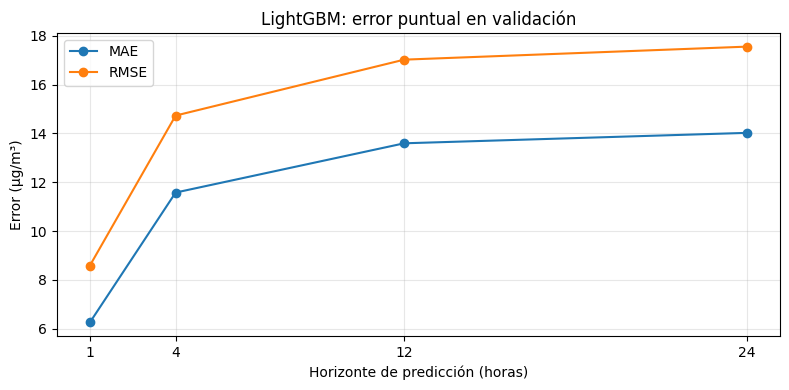

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))

validation_metrics_sorted = validation_metrics_df.sort_values("horizon")

ax.plot(
    validation_metrics_sorted["horizon"],
    validation_metrics_sorted["mae"],
    marker="o",
    label="MAE",
)

ax.plot(
    validation_metrics_sorted["horizon"],
    validation_metrics_sorted["rmse"],
    marker="o",
    label="RMSE",
)

ax.set_title("LightGBM: error puntual en validación")
ax.set_xlabel("Horizonte de predicción (horas)")
ax.set_ylabel("Error (µg/m³)")
ax.set_xticks(HORIZONS)
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()

figure_path = REPORTS_FIGURES_DIR / "fig_lightgbm_point_metrics_validation.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")

print(f"Figura guardada en: {figure_path}")
plt.show()

## Inspección visual sobre un tramo de carácter continuo

Para evitar gráficos con saltos debidos a valores ausentes, se selecciona automáticamente un bloque continuo de horas evaluables en validación. Esta figura es solo ilustrativa: como es lógico, las métricas se calcularán sobre todas las observaciones evaluables del conjunto de validación.

Tramo seleccionado: 2024-01-16 14:00:00 → 2024-01-30 13:00:00 (336 horas)
Figura guardada en: c:\trabajo_github\reports\figures\fig_lightgbm_validation_zoom_h04.png


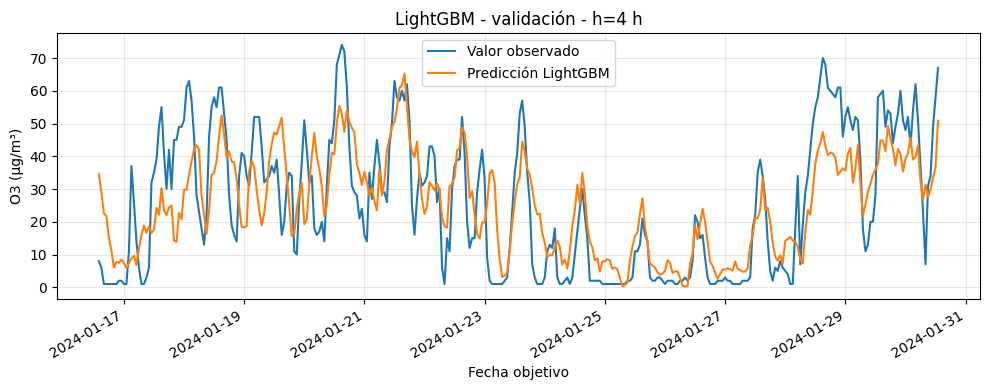

In [12]:
def select_continuous_evaluable_block(
    predictions: pd.DataFrame,
    horizon: int,
    n_hours: int,
) -> pd.DataFrame:
    """Selecciona el primer bloque continuo de horas evaluables.

    Se consideran evaluables las filas que contienen tanto una valor real como una predicción.
    """
    example = predictions.loc[predictions["horizon"] == horizon].copy()
    example = example.sort_values("target_timestamp")
    example = example.dropna(subset=["y_true", "y_pred"]).copy()

    if example.empty:
        raise ValueError(f"No hay observaciones evaluables para h={horizon}.")

    example["delta_h"] = (
        example["target_timestamp"].diff() / pd.Timedelta(hours=1)
    )

    example["continuous_block"] = (
        example["delta_h"].isna() | (example["delta_h"] != 1)
    ).cumsum()

    block_summary = (
        example
        .groupby("continuous_block")
        .agg(
            start=("target_timestamp", "min"),
            end=("target_timestamp", "max"),
            n_hours=("target_timestamp", "count"),
        )
        .reset_index()
    )

    candidate_blocks = block_summary.loc[block_summary["n_hours"] >= n_hours]

    if candidate_blocks.empty:
        selected_block_id = (
            block_summary
            .sort_values(["n_hours", "start"], ascending=[False, True])
            .iloc[0]["continuous_block"]
        )
        print(
            f"No se encontró un bloque continuo de {n_hours} horas. "
            "Se utilizará el bloque continuo más largo disponible."
        )
    else:
        selected_block_id = (
            candidate_blocks
            .sort_values("start")
            .iloc[0]["continuous_block"]
        )

    selected_block = example.loc[
        example["continuous_block"] == selected_block_id
    ].copy()

    return selected_block.head(n_hours)


example_zoom = select_continuous_evaluable_block(
    predictions=predictions_df,
    horizon=EXAMPLE_HORIZON,
    n_hours=EXAMPLE_HOURS,
)

print(
    "Tramo seleccionado:",
    example_zoom["target_timestamp"].min(),
    "→",
    example_zoom["target_timestamp"].max(),
    f"({len(example_zoom)} horas)",
)

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    example_zoom["target_timestamp"],
    example_zoom["y_true"],
    label="Valor observado",
)

ax.plot(
    example_zoom["target_timestamp"],
    example_zoom["y_pred"],
    label="Predicción LightGBM",
)

ax.set_title(f"LightGBM - validación - h={EXAMPLE_HORIZON} h")
ax.set_xlabel("Fecha objetivo")
ax.set_ylabel("O3 (µg/m³)")
ax.grid(True, alpha=0.3)
ax.legend()

fig.autofmt_xdate()
fig.tight_layout()

figure_path = REPORTS_FIGURES_DIR / f"fig_lightgbm_validation_zoom_h{EXAMPLE_HORIZON:02d}.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")

print(f"Figura guardada en: {figure_path}")
plt.show()

## Importancia de variables

LightGBM proporciona medidas internas para la importancia de las variables. En este notebook se guardan dos variantes:

- `importance_gain`: la ganancia acumulada asociada a las divisiones que usa cada variable
- `importance_split`: el número de veces que la variable se utiliza para dividir nodos

Estas medidas tienen un mero carácter diagnóstico. La fase de explicabilidad principal se realizará posteriormente con SHAP.

,model,horizon,feature,importance_gain,importance_split
0,lightgbm,1,o3_at_origin,2.005561e+08,1194
1,lightgbm,1,target_hour_cos,5.599410e+06,611
2,lightgbm,1,o3_lag_1h,5.189761e+06,505
3,lightgbm,1,o3_prev_day_same_hour,1.678960e+06,289
4,lightgbm,1,target_hour_sin,9.123147e+05,304
5,lightgbm,1,o3_roll_std_24h,6.095729e+05,337
6,lightgbm,1,o3_roll_mean_24h,6.004356e+05,221
7,lightgbm,1,o3_roll_max_24h,5.295941e+05,192
8,lightgbm,1,o3_target_lag_48h,3.536132e+05,246
9,lightgbm,1,target_month_cos,3.303065e+05,193


Figura guardada en: c:\trabajo_github\reports\figures\fig_lightgbm_feature_importance_h04.png


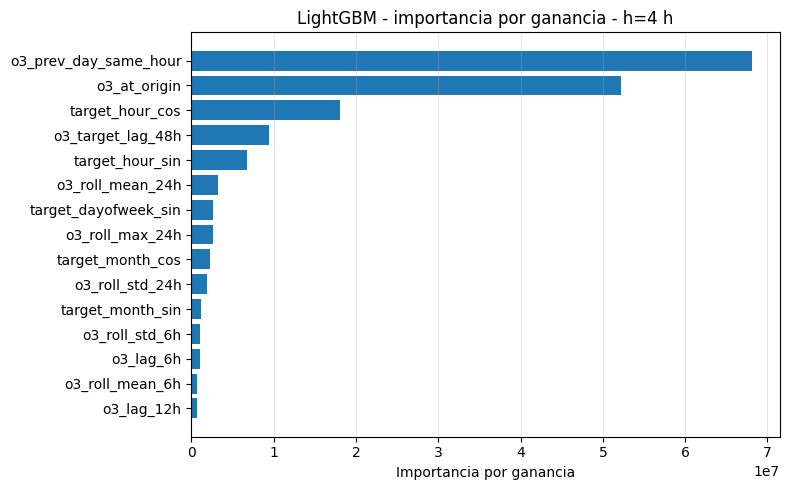

In [13]:
# Mostramos las variables con mayor ganancia por horizonte.
top_importance = (
    feature_importance_df
    .sort_values(["horizon", "importance_gain"], ascending=[True, False])
    .groupby("horizon")
    .head(10)
    .reset_index(drop=True)
)

display(top_importance)

# Figura de importancia para el horizonte de ejemplo.
importance_example = (
    feature_importance_df.loc[feature_importance_df["horizon"] == EXAMPLE_HORIZON]
    .sort_values("importance_gain", ascending=False)
    .head(15)
    .sort_values("importance_gain", ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    importance_example["feature"],
    importance_example["importance_gain"],
)

ax.set_title(f"LightGBM - importancia por ganancia - h={EXAMPLE_HORIZON} h")
ax.set_xlabel("Importancia por ganancia")
ax.grid(True, axis="x", alpha=0.3)

fig.tight_layout()

figure_path = REPORTS_FIGURES_DIR / f"fig_lightgbm_feature_importance_h{EXAMPLE_HORIZON:02d}.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")

print(f"Figura guardada en: {figure_path}")
plt.show()

## Comprobaciones finales

Las comprobaciones finales nos permiten verificar que:

- Se han generado los modelos para los cuatro horizontes
- Se han guardado las predicciones de validación
- Se han guardado los resultados de la validación interna y los hiperparámetros seleccionados
- No se ha utilizado el conjunto de prueba
- Las predicciones no contienen valores ausentes
- Las variables se mantienen dentro del conjunto definido en el notebook de ingeniería de características

In [14]:
expected_model_files = [
    MODELS_DIR / f"lightgbm_h{horizon:02d}.joblib"
    for horizon in HORIZONS
]

expected_prediction_files = [
    REPORTS_PREDICTIONS_DIR / f"lightgbm_h{horizon:02d}.parquet"
    for horizon in HORIZONS
]

expected_table_files = [
    metrics_path,
    training_summary_path,
    cv_results_path,
    cv_folds_path,
    best_params_path,
    feature_importance_path,
]

missing_files = [
    path for path in expected_model_files + expected_prediction_files + expected_table_files
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(f"No se han generado los siguientes archivos esperados: {missing_files}")

if (predictions_df["split"] == "test").any():
    raise AssertionError(
        "Se han generado predicciones sobre el conjunto de prueba, lo cual no corresponde en esta fase."
    )

if predictions_df["y_pred"].isna().any():
    raise AssertionError("Existen predicciones ausentes.")

for horizon in HORIZONS:
    n_features = len(feature_columns_by_horizon.get(str(horizon), default_feature_columns))
    if n_features > MAX_EXPECTED_FEATURES:
        raise AssertionError(
            f"El horizonte {horizon} supera el número máximo de variables previsto."
        )

if set(best_params_df["horizon"]) != set(HORIZONS):
    raise AssertionError("No se han seleccionado hiperparámetros para todos los horizontes.")

if set(validation_metrics_df["horizon"]) != set(HORIZONS):
    raise AssertionError("No hay métricas de validación para todos los horizontes.")

final_check_df = pd.DataFrame(
    {
        "check": [
            "modelos_guardados",
            "predicciones_guardadas",
            "tablas_guardadas",
            "sin_predicciones_test",
            "sin_predicciones_nan",
            "features_compactas",
            "hiperparametros_por_horizonte",
        ],
        "status": [
            all(path.exists() for path in expected_model_files),
            all(path.exists() for path in expected_prediction_files),
            all(path.exists() for path in expected_table_files),
            not (predictions_df["split"] == "test").any(),
            not predictions_df["y_pred"].isna().any(),
            all(
                len(feature_columns_by_horizon.get(str(horizon), default_feature_columns)) <= MAX_EXPECTED_FEATURES
                for horizon in HORIZONS
            ),
            set(best_params_df["horizon"]) == set(HORIZONS),
        ],
    }
)

display(final_check_df)

print("Comprobaciones finales superadas.")

,check,status
0,modelos_guardados,True
1,predicciones_guardadas,True
2,tablas_guardadas,True
3,sin_predicciones_test,True
4,sin_predicciones_nan,True
5,features_compactas,True
6,hiperparametros_por_horizonte,True


Comprobaciones finales superadas.
